# Machine learning

This notebook introduces some of the most commonly used machine learning techniques for processing 3D pointclouds. Unlike purely geometric approaches, these methods leverage both geometric structure and **statistical properties** of the data while remaining **interpretable and efficient**.

Machine learning algorithms often outperform classical methods for tasks such as **outlier detection** and **object segmentation**, and also extend to more advanced applications like **semantic segmentation**.

In [1]:
# Necessary imports
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KDTree, kneighbors_graph, LocalOutlierFactor
from sklearn.cluster import MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier

## Cleaning

As a reminder, the goal of cleaning is to reduce both the number of outliers and the level of noise affecting a pointcloud, as these can impact subsequent processing steps (see the notebook on cleaning). 

From a machine learning perspective, outlier detection can be framed as a subtask of **unsupervised learning**, often referred to as **anomaly detection**, where the goal is to find points that are "different" from the rest of the data, without using labeled examples.

Although there is a lot of work on *anomaly detection*, this section focuses on the **Local Outlier Factor (LOF)**, which extends the neighborhood-based principles of traditional techniques in a more adaptive way.

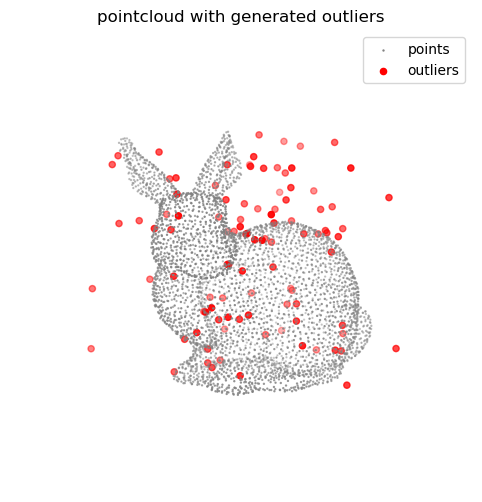

In [2]:
# Load our bunny pointcloud
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
points = data[:, :3]
normals = data[:, 9:12]

# Add outliers to the pointcloud
n_outliers = 100
outliers = np.random.uniform(
    points.min(axis=0),
    points.max(axis=0),
    (n_outliers, 3)
)
points_outliers = np.vstack((points, outliers))
# Create a mask to identify the outliers in the combined pointcloud
outliers_mask_true = np.hstack((np.zeros(points.shape[0], dtype=bool),
                                np.ones(outliers.shape[0], dtype=bool)))

# Visualize the pointcloud with outliers
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2],
           c="red", label="outliers")
ax.set_box_aspect([1, 1, 1])
ax.view_init(10, 60)
ax.set_axis_off()
ax.legend()
ax.set_title("pointcloud with generated outliers")
plt.show()

The most commonly used traditional outlier detection techniques, namely *Statistical Outlier Removal* (SOR) and *Radius Outlier Removal* (ROR), rely on the assumption of a globally consistent point density, using fixed thresholds based on distances or neighborhood sizes to identify outliers. As a result, they often struggle when the density varies across the pointcloud, since a single global criterion cannot adapt to heterogeneous regions. A natural improvement is therefore to account for local variations in the data distribution rather than applying a uniform rule.

This is precisely the idea behind the **Local Outlier Factor (LOF)**, which adopts an **unsupervised learning approach** by estimating the local density of each point and comparing it to that of its neighbors \cite{breunig2000lof}. By relying on relative density instead of absolute thresholds, LOF is able to automatically adapt to spatial heterogeneity and detect more subtle anomalies in complex pointclouds.

LOF can be applied directly to point coordinates or extended to higher-dimensional feature spaces by incorporating additional attributes such as intensity, color, normals, or eigenvalue-based descriptors. This is an additional advantage over more traditional techniques that rely solely on geometric Euclidean distances. However, careful feature selection and proper data normalization are essential to ensure meaningful results.

LOF computation for given point $p_{i}$ follows these steps:

1. Query the $k$-nearest neighbors of $p_{i}$ and form the set $N_{i}$.

2. Compute the $k$-distance of each neighbor $p_{j} \in N_{i}$, which corresponds to the distance between $p_{j}$​ and its $k$-th nearest neighbor:
\begin{equation*}
    k\text{-dist}(p_{j})
\end{equation*}

3. Define the reachability distance between $p_i$​ and each neighbor $p_j$:
\begin{equation*}
    \text{reach-dist}_{k}(p_{i}, p_{j}) = \max (k\text{-dist}(p_{j}), d(p_{i}, p_{j}))
\end{equation*}

4. Estimate the local reachability density (LRD) of $p_{i}$​:
\begin{equation*}
    LRD_{k}(p_{i}) = (\frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} \text{reach-dist}_{k}(p_{i}, p_{j}))^{-1}
\end{equation*}

5. Compute the Local Outlier Factor (LOF) of $p_{i}$​ by comparing its density to that of its neighbors
\begin{equation*}
    LOF_{k}(p_{i}) = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} \frac{LRD_{k}(p_{j})}{LRD_{k}(p_{i})}
\end{equation*}

As a result, LOF assigns a score to each point measuring how isolated it is with respect to its local neighborhood. Values close to 1 indicate inliers, while significantly larger values indicate potential outliers.

LOF is conceptually straightforward and can be directly implemented using Python main scientific libraries. The ```scikit-learn``` library also provides an out-of-the box implementation called ```LocalOutlierFactor```, which is used in the example below.

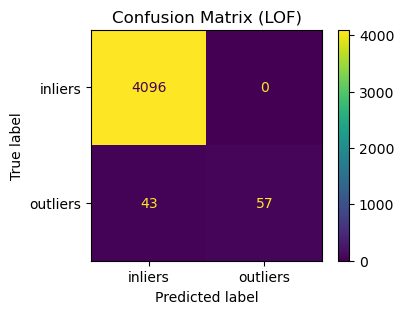

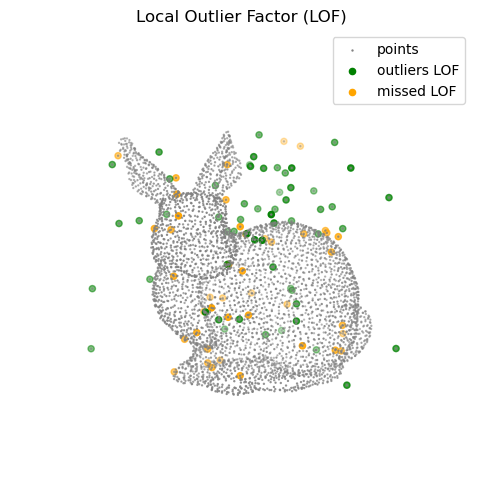

In [3]:
# Detect outliers using Local Outlier Factor (LOF)
clf_lof = LocalOutlierFactor(n_neighbors=10)
y_pred = clf_lof.fit_predict(points_outliers)
outlier_mask_lof = y_pred == -1
outliers_lof = points_outliers[outlier_mask_lof]
missed_mask_lof = np.logical_xor(outlier_mask_lof, outliers_mask_true)
missed_lof = points_outliers[missed_mask_lof]

# Evaluate the performance of LOF using a confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
cmd_lof = ConfusionMatrixDisplay.from_predictions(
    outliers_mask_true, outlier_mask_lof,
    display_labels=["inliers", "outliers"],
    ax=ax
)
ax.set_title("Confusion Matrix (LOF)")
plt.show()

# Visualize the inliers and outliers
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_outliers[:, 0], points_outliers[:, 1], points_outliers[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers_lof[:, 0], outliers_lof[:, 1], outliers_lof[:, 2],
           c="green", label="outliers LOF")
ax.scatter(missed_lof[:, 0], missed_lof[:, 1], missed_lof[:, 2],
           c="orange", label="missed LOF")
ax.set_box_aspect([1, 1, 1])
ax.view_init(10, 60)
ax.set_axis_off()
ax.legend()
ax.set_title("Local Outlier Factor (LOF)")
plt.show()

## Object Segmentation

As a reminder, object segmentation in 3D pointclouds aims to group points that belong to the same physical object. In practice, each object corresponds to a set of nearby points and segmentation seeks to identify and separate these sets. 

This goal is closely aligned with **clustering**, a core concept in **unsupervised learning**, which consists of partition data into groups based on similarity without relying on labeled examples. As a result, clustering algorithms provide a natural and flexible framework for object segmentation.

The following subsections explore how classical clustering methods such as KMeans, DBSCAN, and Agglomerative Clustering can be applied to segment 3D pointclouds.

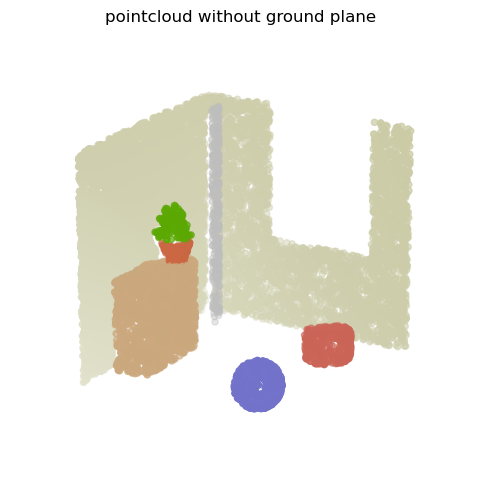

In [4]:
# Load synthetic indoor scene pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points, colors, normals = data[:, :3], data[:, 6:9], data[:, 9:12]

# Remove points belonging to the ground plane (z = 0)
ground_mask = points[:, 2] < 0.05
points_no_ground = points[~ground_mask]
colors_no_ground = colors[~ground_mask]
normals_no_ground = normals[~ground_mask]

# Visualize the original pointcloud and the points without the ground plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
            c=colors_no_ground)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("pointcloud without ground plane")
plt.show()


### K-means

KMeans is one of the most widely used clustering algorithms and is sometimes considered for object segmentation in 3D point clouds. It **partitions the data into a fixed number of clusters by minimizing the distance between each point and its assigned cluster centroid**.

Because KMeans tends to produce compact and roughly spherical clusters, it is rarely applied to raw spatial coordinates alone. Instead, it is typically used with enriched feature representations, combining position with attributes such as color or intensity. In practice, careful feature selection and proper normalization are essential to ensure stable and meaningful results.

However, the reliance on centroid distance introduces several important limitations. Nearby objects may be grouped into a single cluster, and the method implicitly **assumes clusters of similar size and convex shape**. It does not enforce spatial continuity and struggles with varying point densities, which are common in real-world data. In addition, the number of clusters must be specified *a priori*, although heuristic methods such as the *elbow curve* can help estimate a suitable value *a posteriori*.

These limitations make KMeans not much used in practice for complex scenes. The example below even underlines its limitation on our rather simple synthetic indoor scene. Note that the implementation below uses ```MiniBatchKMeans```, which is a variant of the KMeans algorithm which uses mini-batches to reduce the computation time. A ```StandardScaler``` is applied to normalize the features.

c:\Users\frup00090363\AppData\Local\miniconda3\envs\sci\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


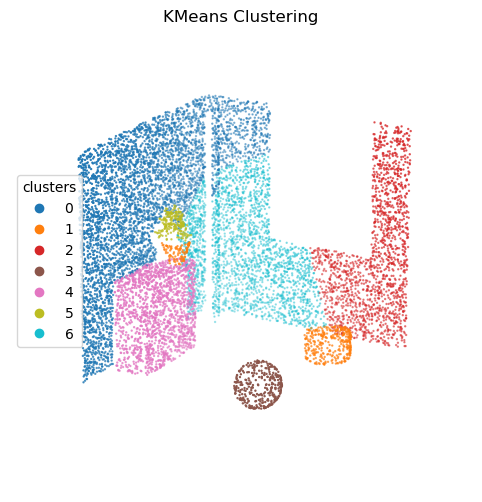

In [5]:
# Stack points and colors into a feature matrix X
X_kmeans = np.hstack((points_no_ground, colors_no_ground))
# Standardize features
X_kmeans = StandardScaler().fit_transform(X_kmeans)
# KMeans clustering with a chosen number of clusters
labels_kmeans = MiniBatchKMeans(n_clusters=7, n_init=10).fit_predict(X_kmeans)

# Visualize KMeans clustering results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
                     c=labels_kmeans, cmap="tab10", s=0.5)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("KMeans Clustering")
ax.legend(*scatter.legend_elements(), title="clusters", loc="center left")
plt.show()

### DBSCAN

DBSCAN is a density-based clustering algorithm that is particularly well-suited for 3D pointclouds. It groups points based on spatial proximity and local density, using a distance threshold to connect neighboring points. Unlike KMeans, DBSCAN does not require specifying the number of clusters in advance and can naturally detect outliers as noise, making it robust in cluttered scenes.

Additional features such as color or normals can help better separate objects, but they also increase the feature space dimension. In high dimensions, distances become less meaningful and neighborhoods more sparse, which can degrade performance. To address this, it is common to either weight features carefully or decouple the problem (for example, first clustering in XYZ space, then refining clusters using additional features).

The implementation below uses the ```DBSCAN``` algorithm from ```scikit-learn```.

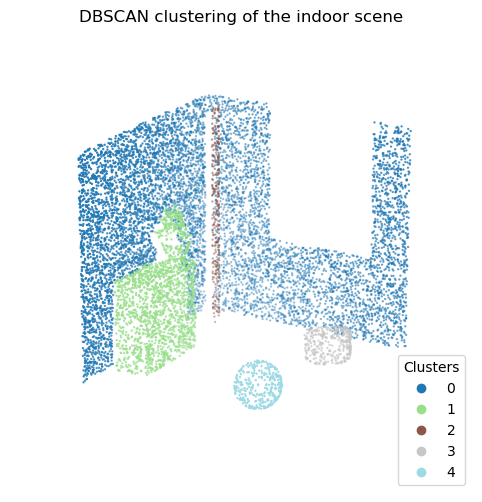

In [6]:
# DBSCAN clustering to segment the scene
labels_dbscan = DBSCAN(eps=100., min_samples=20).fit_predict(points_no_ground)

# Visualize the clustered pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
                     c=labels_dbscan, cmap="tab20", s=0.5)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("DBSCAN clustering of the indoor scene")
ax.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

### Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method that progressively builds clusters by merging nearby points or groups of points. Starting from individual points, it iteratively combines the closest clusters according to a chosen linkage criterion, producing a hierarchy that can be cut at different levels to obtain a segmentation.

A key advantage for pointcloud segmentation is the ability to incorporate a connectivity matrix, which restricts merges to spatially neighboring points and helps preserve local structure. This makes the method well-suited for refining structured regions such as walls, roofs, or indoor partitions. However, its computational cost is high, which makes it more appropriate as a refinement step rather than a first clustering approach. Agglomerative clustering also sometimes used in surface segmentation and simplification \cite{pauly2002efficient}, following the same strategy of merging groups of points based on similarity.

The implementation below uses the ```AgglomerativeClustering``` algorithm from ```scikit-learn```. A ```kneighbors_graph``` is used to define connectivity and a ```StandardScaler``` is applied to normalize the features.

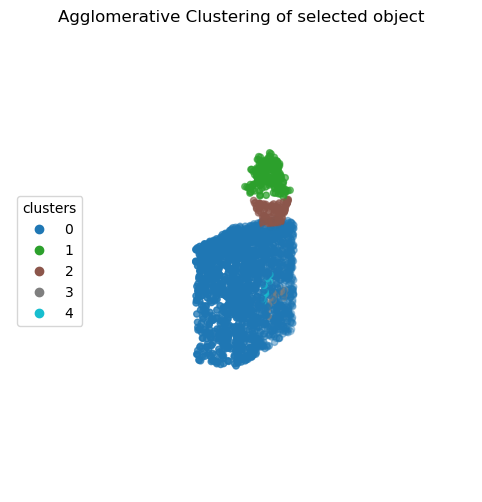

In [ ]:
# Select a cluster of interest from the DBSCAN results
object_mask = labels_dbscan == 1
points_object = points_no_ground[object_mask]
points_object -= points_object.mean(axis=0)  # center the object 
normals_object = normals_no_ground[object_mask]
colors_object = colors_no_ground[object_mask]

# Stack features for Agglomerative Clustering (only normals and colors)
X_agglo = np.hstack((normals_object, colors_object))
X_agglo = StandardScaler().fit_transform(X_agglo)
# Compute the connectivity matrix from the coordinates of the points
connectivity = kneighbors_graph(points_object, n_neighbors=10,
                                mode='connectivity', include_self=False)
# Perform Agglomerative Clustering with connectivity constraints
labels_agglo = AgglomerativeClustering(
    n_clusters=5,
    connectivity=connectivity,
    linkage="ward"
    ).fit_predict(X_agglo)

# Visualize Agglomerative Clustering results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_object[:, 0], points_object[:, 1], points_object[:, 2],
                     c=labels_agglo, cmap="tab10")
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("Agglomerative Clustering of selected object")
ax.legend(*scatter.legend_elements(), title="clusters", loc="center left")
plt.axis("equal")
plt.show()


## Semantic Segmentation

In machine learning, semantic segmentation is a task within **supervised learning**, where a model is trained on labeled data to assign a class to each individual element of an input. Applied to 3D point clouds, **semantic segmentation consists of predicting a semantic label for every point** (e.g., *car*, *tree*, *road*). This enables the interpretation of complex 3D scenes, including urban and natural environments as well as indoor spaces, using high-level semantic information.

In a "traditional" machine learning framework (excluding deep learning), semantic segmentation is typically structured into four key steps:

1. Definition of **neighborhoods** around each point to capture its local context

2. Computation of **descriptors** that describe the geometry of these neighborhoods

3. Selection and tuning of a **classifier** to assign a semantic label based on these descriptors

4. Contextual **regularization** to enforce spatial consistency of the predictions (Optional)

The design of efficient neighborhoods, discriminative descriptors, suitable classifiers, and spatial regularization strategies for semantic segmentation has been extensively explored in the literature \cite{demantke2011dimensionality, niemeyer2014contextual, weinmann2015semantic, hackel2016fast}. The following paragraphs try to summarize key practical insights derived from existing works.

The example below comes from the IGN LiDAR HD dataset, a dense airborne LiDAR dataset providing a detailed 3D representation of landscapes in France, with an average density of about 10 points per square meter \cite{ign_lidar_hd}. The original pointcloud is classified into 11 categories, including eight standard ASPRS classes and three custom classes. For clarity and to reduce complexity, the point cloud is simplified to three classes (*ground*, *vegetation*, and *building*) by merging vegetation subclasses (*low*, *medium*, and *high vegetation*) and excluding less relevant categories such as *water* and *not classified*.

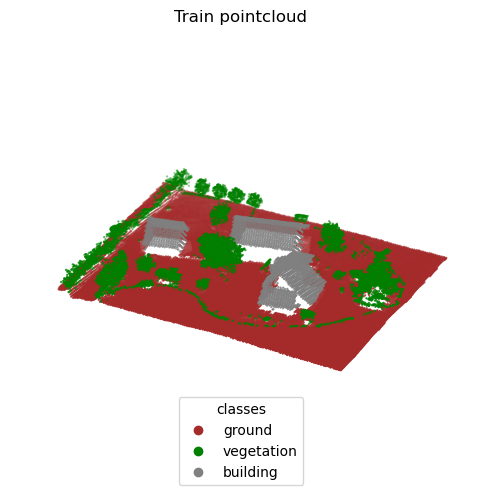

In [8]:
# Load LHD training data
data = np.loadtxt("./data/LHD_train.xyz", dtype=np.float32)
points, intensity, y_train = data[:, :3], data[:, 3], data[:, 4]
class_names = {0: "ground", 1: "vegetation", 2: "building"}

# Spatial structure
kdtree = KDTree(points)

# Visualize the pointcloud colored by class labels
lidar_cmap = matplotlib.colors.ListedColormap(["brown", "green", "gray"])
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=y_train, cmap=lidar_cmap, s=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Train pointcloud")
# Create legend with class names
legend_handles = []
legend_labels = []
for cls in class_names.keys():
    color = lidar_cmap(cls)
    legend_handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                                     color=color, markersize=6))
    legend_labels.append(class_names[int(cls)])
ax.legend(legend_handles, legend_labels, title="classes", loc="lower center")
plt.show()


### Neighborhoods

The first step of the semantic segmentation pipeline is the **definition of neighborhoods**, which directly impacts the scale of the analysis.

Neighborhoods are usually characterized by their geometric **nature** (spatial support) and their **scale** (spatial extent).

Common neighborhood types include:

* **$k$-neighborhoods**, defined by the $k$ closest points. They naturally adapt to varying point densities, but their spatial extent varies across the scene.

* **Spherical neighborhoods**, consisting of all points within a 3D sphere of a given radius around a point. They provide a fixed spatial extent, but the number of contained points varies with local density.

* **Cylindrical neighborhoods**, consisting of points whose projection falls within a circle on a reference plane (e.g., the ground plane). They are well suited to scenes with a dominant vertical direction, but may connect points that are very far apart in elevation.

* **Voxel-based neighborhoods**, defined by grouping points within the same voxel. They enable efficient spatial indexing and processing, but remain sensitive to density variations and voxel size selection.

The neighborhood scale can be selected using different strategies:

* **Fixed-scale neighborhoods**, using a constant radius or a fixed number of neighbors. They are simple to implement, but may not adapt well to varying densities or object sizes.

* **Adaptive single-scale neighborhoods**, where the neighborhood size is selected independently for each point based on local geometric criteria. They better capture local geometry, but require additional computation.

* **Multi-scale neighborhoods**, where features are computed at several predefined neighborhood sizes. They capture geometric information at different levels of detail, but increase both computational cost and feature dimensionality.

* **Adaptive multi-scale neighborhoods**, where multiple scales are combined through data-driven selection or weighting. They offer greater flexibility and robustness, but are more complex to design and compute.


One popular adaptive single-scale strategy determines the "optimal" neighborhood size by evaluating the eigentropy $E_{\lambda}$ (computed from the normalized eigenvalues of the local covariance matrix, see notebook about descriptors) over a range of scales $k \in [k_{\min}, k_{\max}]$. The selected size is the one  minimizing $E_{\lambda}$​, corresponding to the local geometry with the lowest uncertainty according to a Shannon entropy-based criterion.

Although an adaptive single-scale strategy leads to locally "optimal" neighborhoods, a single scale rarely captures all relevant geometric information present in complex scenes. In practice, **multi-scale neighborhoods remain the most effective and popular strategy**, because they capture geometry at different levels of detail. A common baseline is to **use 3 to 6 scales with a logarithmic progression**, small scales capturing local geometry, medium scales describing object parts, and larger scales providing full object context.

In the case of airborne LiDAR pointclouds such as the one presented above, k-neighborhoods are generally preferred since they better handle density variations and result in more stable features. For a density of approximately 10 pts/m² (average point spacing around 30 cm), neighborhood sizes of $k = [10, 20, 50]$ typically capture geometric information ranging from local surface details to object-level context. These values provide a reasonable initial configuration but may be refined later based on classification results.

In [9]:
# k values used for multiscale neighborhoods
k_values_multiscale = [10, 20, 50]

### Descriptors

The second key step of the semantic segmentation pipeline is the **computation of descriptors** or features, which characterize the local geometry and attributes of each point based on its neighborhood.

Common types of features include:

* **Eigenvalue-based features** (e.g., linearity, planarity, scattering), capturing the local 3D shape.

* **Height-based features** (e.g., height above ground, height range), describing the vertical position of points.

* **Density-based features** (e.g., point density, spacing), characterizing the local point distribution.

* **Angle-based features** (e.g., verticality, normal variation), describing surface orientation and smoothness.

* **Histogram-based features** (e.g., FPFH, SHOT), encoding distributions of geometric relationships within the neighborhood.

* **Radiometric features** (e.g., intensity and intensity statistics), linked to the reflectance properties of the scanned materials (when available from sensor).

* **RGB features** (e.g., colors, color gradients and statistics), incorporating spectral information (when available from sensor).

Additionally, some of these descriptors can also be computed from a 2D projection (e.g. onto the ground plane), providing complementary information in structured environments where horizontal organization is meaningful.

In practice, **eigenvalue-based, height-based and density-based features remain among the most widely used descriptors** for semantic segmentation, as they provide a good compromise between discriminative power, robustness and computational efficiency. More sophisticated descriptors such as FPFH or SHOT may capture richer geometric patterns but are generally more computationally expensive.

These implementations below compute the $k$ nearest neighbors for all points at once and use vectorized operations whenever possible instead of explicit loops. While improving execution speed, it is also memory-intensive and switching to batch processing is advised for large pointclouds. Height, density and angle-based features are grouped into the "geometric features" category. Separate functions are used for eigenvalue-based features and geometric features for clarity and readability, although grouping them would reduce redundant neighborhood computations. The ```indices``` parameter enables descriptor computation on a subset of points only (useful for adaptive neighborhoods for example).

In [10]:
def compute_3D_eigen_features(points, neighbor_finder, norm_eigenvalues=True,
                              indices=None):
    """"Compute normals and principal eigenvalue-based features."""

    # Neighbors for all query points
    query_points = points if indices is None else points[indices]
    inds = neighbor_finder(query_points) # (N, k)
    k = inds.shape[-1]
    neighbors = points[inds]
    # Eigenvalues from covariance matrix
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k  # (N, 3, 3)
    eigenvalues, eigenvectors = np.linalg.eigh(cov) # (N, 3), (N, 3, 3)
    eigenvalues = np.clip(eigenvalues, 1e-10, None) # fix numerical negatives
    # Normals
    normals = eigenvectors[:,:,0]
    # Compute sum before normalization (equal to 1. if normalized)
    eigensum = eigenvalues.sum(axis=1)
    # Normalize eigenvalues if required
    if norm_eigenvalues:
        eigenvalues /= eigenvalues.sum(axis=1, keepdims=True)
    # Compute features based on eigenvalues
    lambda_1 = eigenvalues[:, 2]
    lambda_2 = eigenvalues[:, 1]
    lambda_3 = eigenvalues[:, 0]
    linearity = (lambda_1 - lambda_2) / lambda_1
    planarity = (lambda_2 - lambda_3) / lambda_1
    scattering = lambda_3 / lambda_1
    omnivariance = (lambda_1 * lambda_2 * lambda_3) ** (1/3)
    anisotropy = (lambda_1 - lambda_3) / lambda_1
    eigentropy = -np.sum(eigenvalues * np.log(eigenvalues), axis=1)
    curvature = lambda_3 / (lambda_1 + lambda_2 + lambda_3)

    return (normals, linearity, planarity, scattering, omnivariance, 
            anisotropy, eigentropy, eigensum, curvature)

The 3D eigenvalue-based features have already been introduced in the previous notebook on descriptors. One important thing to remember is that the eigensum should not be normalized. If so, its value becomes the same (equal to 1) for every point, which is not useful for training or prediction.

Normals are computed at the same time and at different scales. Another option is to compute normals separately as a preprocessing step, using a different (adaptive) scale, as shown in the notebook about normals and curvatures. For aerial data, normals can be easily oriented using the sensor position and direction, so they point upward (toward $z^{+}$).

In [12]:
# Compute normals and 3D eigenvalue-based features
normals_multiscale = []
eigenfeatures_3D_multiscale = []
eigenfeatures_3D_names = []

for k in k_values_multiscale:
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=False)
    eigenfeatures_3D_k = compute_3D_eigen_features(points, neighbor_finder)
    # Remove normals from eigenfeatures list (computed at same time)
    normals_k = eigenfeatures_3D_k[0]
    eigenfeatures_3D_k = eigenfeatures_3D_k[1:]
    # Orient normals consistently towards +z direction (acquisition direction)
    mask_n = normals_k[:, 2] < 0
    normals_k[mask_n] = -normals_k[mask_n]
    # Store results
    normals_multiscale.append(normals_k)
    eigenfeatures_3D_multiscale.append(eigenfeatures_3D_k)
    eigenfeatures_3D_names.extend([
        f"linearity_{k}", f"planarity_{k}", f"scattering_{k}", f"omnivariance_{k}", 
        f"anisotropy_{k}", f"eigentropy_{k}", f"eigensum_{k}", f"curvature_{k}"
    ])

# Concatenate all multiscale features in one array of shape (N, 8*k)
eigenfeatures_3D_multiscale = np.stack(
    [arr for tup in eigenfeatures_3D_multiscale for arr in tup],
    axis=1
)

Contrary to eigenvalue-based features, geometric features capture the global or contextual position  of each point in the scene, rather than the local shape of its neighborhood. The tables below list some of the most used height-based, density-based and angle-based features.

Height-based features assume a prefered direction for height, often $z$. Features are computed withing each neighborhood but also relatively to the ground thanks to a *Digital Terrain Model* (DTM), which represents the bare-earth surface. A DTM is typically created as a preprocessing step by extracting ground points from the data and building a surface that represents the terrain height (not covered here). Height-based features typically help to capture elevated objects such as buildings or vegetation.

| Feature           | Formula             | Intuitive meaning                    |
|-------------------|---------------------|--------------------------------------|
| Normalized height | $z - z_{ground}$    | Height relative to ground (need DTM) |
| Height variation  | $std (z)$           | Height variation within neighborhood |
| Height range      | $z_{max} - z_{min}$ | Height range within neighborhood     |  

Density-based features describe how points are distributed in space. They provide information about how crowded or sparse a local region is, which can help differentiate between solid structures and more irregular or scattered objects.

| Feature                | Formula                     | Intuitive meaning                     |
|------------------------|-----------------------------|---------------------------------------|
| Density                | $k / \frac{4}{3} \pi r^{3}$ | Local density                         |
| Radius (knn distance)  | $r = d_{knn}$               | Size of the local neighborhood        |
| Mean neighbor distance | $1/k \sum d_i$              | Average spacing between nearby points |

Angle-based features rely on the orientation of the local surface, typically derived from normal vectors. They capture how much local surface varies in orientation, making it easier to identify horizontal/vertical or highly irregular structures.
 
| Feature           | Formula         | Intuitive meaning                  |
|-------------------|-----------------|------------------------------------|
| Verticality       | $1 - \|n_{z}\|$ | How "upright" the local surface is |
| Angular variation | $std (n)$       | Variation of surface orientation   |


In [13]:
def compute_3D_geometric_features(points, normals, neighbor_finder,
                                  indices=None):
    """Compute 3D features"""

    # Neighbors for all query points
    query_points = points if indices is None else points[indices]
    query_normals = normals if indices is None else normals[indices]
    dists, inds = neighbor_finder(query_points)  # (N, k)
    k = inds.shape[-1]
    # Density
    radius = dists[:, -1]
    density = k / ((4/3) * np.pi * radius**3)
    mean_dists = np.mean(dists, axis=1)
    # Height
    knn_z_coords = points[inds, 2] # (N, k)
    d_z = knn_z_coords.max(axis=1) - knn_z_coords.min(axis=1)
    std_z = knn_z_coords.std(axis=1)
    # Angle (normals are supposed to be oriented, otherwise use abs)
    verticality = 1 - np.abs(query_normals[:, 2])
    normals_dot = np.sum(query_normals[:, None, :] * normals[inds], axis=2) 
    normals_dot = np.clip(normals_dot, -1.0, 1.0) # (N, k)
    angular_variation = np.mean(1 - normals_dot, axis=1)

    return radius, density, mean_dists, d_z, std_z, verticality, angular_variation


In [14]:
# 3D geometric features
geomfeatures_3D_multiscale = []
geomfeatures_3D_names = []

for i, k in enumerate(k_values_multiscale):
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=True,
                                                  sort_results=True)
    
    geomfeatures_3D_k = compute_3D_geometric_features(points,
                                                      normals_multiscale[i],
                                                      neighbor_finder)
    # Store results
    geomfeatures_3D_multiscale.append(geomfeatures_3D_k)
    geomfeatures_3D_names.extend([
        f"radius_{k}", f"density_{k}", f"mean_dists_{k}", f"d_z_{k}",
        f"std_z_{k}", f"verticality_{k}", f"angular_variation_{k}"
    ])

# Concatenate all multiscale features in one array of shape (N, 7*k)
geomfeatures_3D_multiscale = np.stack(
    [arr for tup in geomfeatures_3D_multiscale for arr in tup],
    axis=1
)

Finally, eigenvalue-based and geometric **features computed at multiple scales are concatenated into a single feature vector** (note that intensity is also included here). This feature vector is typically high-dimensional, with up to 150 features being common in practice.

However, not all descriptors are equally informative, and **feature selection is often used to identify the most relevant features** and remove redundant ones. This is a standard machine learning step and is not specific to point cloud semantic segmentation. Feature selection methods can be broadly divided into **filter-based** and **embedded** approaches. Filter methods assess feature relevance independently of any classifier, either by evaluating each feature individually (*univariate* methods) or by accounting for dependencies between features (*multivariate* methods). Embedded methods estimate feature importance directly during classifier training.

**In practice, feature selection is often left to the classifier**, and explicit selection is mainly used to improve performance, reduce dimensionality, or increase interpretability.

In [15]:
# All available features
X_train = np.concatenate(
    [eigenfeatures_3D_multiscale, geomfeatures_3D_multiscale, intensity[:, None]],
    axis=1
)
X_names = np.array(eigenfeatures_3D_names + geomfeatures_3D_names + ["intensity"])

print("Shape of X_train:", X_train.shape)
print("Feature names:", X_names)

Shape of X_train: (49056, 46)
Feature names: ['linearity_10' 'planarity_10' 'scattering_10' 'omnivariance_10'
 'anisotropy_10' 'eigentropy_10' 'eigensum_10' 'curvature_10'
 'linearity_20' 'planarity_20' 'scattering_20' 'omnivariance_20'
 'anisotropy_20' 'eigentropy_20' 'eigensum_20' 'curvature_20'
 'linearity_50' 'planarity_50' 'scattering_50' 'omnivariance_50'
 'anisotropy_50' 'eigentropy_50' 'eigensum_50' 'curvature_50' 'radius_10'
 'density_10' 'mean_dists_10' 'd_z_10' 'std_z_10' 'verticality_10'
 'angular_variation_10' 'radius_20' 'density_20' 'mean_dists_20' 'd_z_20'
 'std_z_20' 'verticality_20' 'angular_variation_20' 'radius_50'
 'density_50' 'mean_dists_50' 'd_z_50' 'std_z_50' 'verticality_50'
 'angular_variation_50' 'intensity']


Before training, it is good practice to **check for class imbalance**. In airborne LiDAR datasets, the ground class often contains many more samples than classes corresponding to smaller objects. As a rule of thumb, if the largest class contains more than 5 to 10 times as many samples as the smallest one, class rebalancing is usually recommended. Otherwise, the classifier may become biased toward the dominant classes.

A simple and widely used solution is **random undersampling**, which consists of keeping the same number of samples for each class in the training set. This **creates a balanced dataset and is often a good first choice when the training set is large**.

However, undersampling removes many samples from dominant classes and may therefore discard useful information. Alternatives include assigning larger weights to minority classes or increasing their number of samples through data augmentation. These approaches are generally preferred when preserving all available samples is important.

The example below illustrates how random undersampling can be applied in practice. Since the considered dataset is only moderately imbalanced and not particularly large, undersampling is shown for demonstration purposes only, and all available samples are ultimately retained for training.

In [16]:
def random_undersample_balance(X_train, y_train, n_samples_per_class=None,
                               random_state=42):
    """Perform random undersampling to balance classes."""
    
    classes = np.unique(y_train)
    # Determine target number of samples per class
    if n_samples_per_class is None:
        class_counts = [np.sum(y_train==c) for c in classes]
        n_samples_per_class = min(class_counts)
    # Sample each class to the target number of samples
    X_list = []
    y_list = []
    for c in classes:
        X_c = X_train[y_train==c]
        y_c = y_train[y_train==c]
        # Random undersampling
        X_resampled, y_resampled = resample(X_c, y_c, replace=False,
            n_samples=n_samples_per_class, random_state=random_state)
        X_list.append(X_resampled)
        y_list.append(y_resampled)
    # Concatenate all classes
    X_balanced = np.vstack(X_list)
    y_balanced = np.concatenate(y_list)
    # Mix classes
    perm = np.random.RandomState(random_state).permutation(len(y_balanced))
    X_balanced = X_balanced[perm]
    y_balanced = y_balanced[perm]

    return X_balanced, y_balanced


In [17]:
# Balance dataset
X_balanced, y_balanced = random_undersample_balance(X_train, y_train)

print("Original shape:", X_train.shape)
print("Balanced shape:", X_balanced.shape)
print("Class distribution:", {class_names[int(c)]: int(np.sum(y_balanced==c)) 
                              for c in np.unique(y_balanced)})

Original shape: (49056, 46)
Balanced shape: (18726, 46)
Class distribution: {'ground': 6242, 'vegetation': 6242, 'building': 6242}


### Classifiers

The third key step of the semantic segmentation pipeline is the **selection and tuning of a classifier**

The list of possible classifiers is large, ranging from simple *k‑Nearest Neighbors* (kNN) to more sophisticated *Support Vector Machines* (SVM). In practice, **Random Forest (RF) remains one of the most widely used baseline classifiers**, offering a good balance between accuracy, robustness, computational efficiency, and ease of use. RF requires little parameter tuning, does not require feature normalization, naturally provides feature importance measures, and can be efficiently parallelized.

More importantly, **the impact of the classifier is often secondary compared to the quality of the input features**. A common mistake is to spend too much effort tuning the classifier while neglecting feature engineering.

The implementation below uses ```scikit-learn``` implementation of ```RandomForestClassifier``` with default mostly settings. A forest of 100 trees already provides good performance in most cases, although larger forests (typically 200–500 trees) may improve prediction stability. Class imbalance is handled through ```class_weight="balanced"```, and training is parallelized using ```n_jobs=-1```.

In [18]:
# Train a Random Forest classifier on all samples and features
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42,
                                class_weight="balanced")
rf_clf.fit(X_train, y_train)

# Evaluate the classifier on the training set
y_pred_train_all = rf_clf.predict(X_train)
print("Classification report on training set (all samples all features):")
print(classification_report(y_train, y_pred_train_all,
                            target_names=class_names.values()))

Classification report on training set (all samples all features):
              precision    recall  f1-score   support

      ground       1.00      1.00      1.00     33428
  vegetation       0.99      1.00      0.99      9386
    building       1.00      1.00      1.00      6242

    accuracy                           1.00     49056
   macro avg       1.00      1.00      1.00     49056
weighted avg       1.00      1.00      1.00     49056



The model achieves near-perfect performance on the training set when using all available features. This likely indicates some degree of overfitting and reflects the simplicity of the classification problem (three well-separated classes) rather than true generalization performance.

Once the classifier has been trained, embedded feature selection is performed by analysing feature importance. For Random Forests, the standard measure is the *Mean Decrease in Impurity* (MDI, available through ```model.feature_importances_```). This metric quantifies the contribution of each feature to the splits performed by the trees. It is computationally inexpensive, but may be biased when features are highly correlated.

An alternative is permutation importance (```sklearn.inspection.permutation_importance```), which estimates feature relevance by measuring the decrease in model performance when the values of a feature are randomly shuffled. This approach is generally more reliable and model-agnostic, but comes at a significantly higher computational cost.

For simplicity and computational efficiency, the examples below rely on the MDI importance provided directly by the Random Forest implementation. The feature selection process confirms that 3D eigenvalue-based features alone are not sufficient to optimally characterize semantic classes, highlighting the importance of complementary features such as height or intensity.

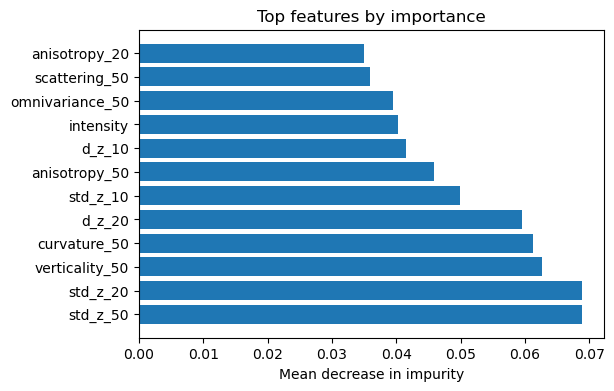

In [19]:
# Compute feature importances
feature_importances = rf_clf.feature_importances_
# Keep only the most important features
top_features = np.flatnonzero(
    feature_importances > np.percentile(feature_importances, 75)
)
# Sort top features by importance
top_features = top_features[np.argsort(feature_importances[top_features])]

# Plot feature importances
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    X_names[top_features],
    feature_importances[top_features]
)
ax.invert_yaxis()  # most important feature at the top
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Top features by importance")
plt.show()


The classifier is then retrained using only the dozen most important features identified by the Random Forest. No significant drop in training performance is observed, indicating that most of the discriminative information is captured by a small subset of descriptors. In practice, reducing the number of features also helps decrease memory usage, speed up training and inference, and improve model interpretability.

In [20]:
# Retrain with only the top features
X_train = X_train[:, top_features]

# Retrain the Random Forest classifier with the top features
rf_clf.fit(X_train, y_train)
y_pred_train_top = rf_clf.predict(X_train)
print("Classification report on training set (all samples top features):")
print(classification_report(y_train, y_pred_train_top, 
                            target_names=class_names.values()))

Classification report on training set (all samples top features):
              precision    recall  f1-score   support

      ground       1.00      0.99      1.00     33428
  vegetation       0.98      1.00      0.99      9386
    building       0.99      1.00      1.00      6242

    accuracy                           1.00     49056
   macro avg       0.99      1.00      0.99     49056
weighted avg       1.00      1.00      1.00     49056



The classifier is then evaluated on the test set below. It consists of a different tile from the IGN LiDAR HD dataset (which was not used during training). This provides a more realistic estimate of the model's ability to generalize to unseen data.

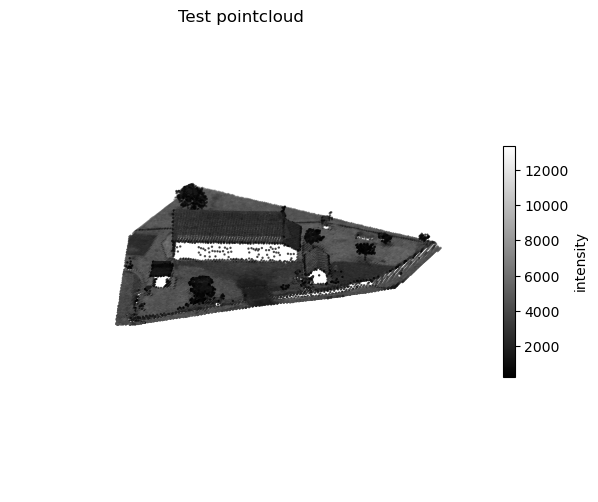

In [21]:
# Load test pointcloud and compute features (similar to training)
data_test = np.loadtxt("./data/LHD_test.xyz")
points, intensity, y_test = data_test[:, :3], data_test[:, 3], data_test[:, 4]

# Spatial structure
kdtree = KDTree(points)

# Visualize the test pointcloud colored by intensity
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                     c=intensity, cmap="gray", s=0.5)
fig.colorbar(scatter, ax=ax, label="intensity", shrink=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Test pointcloud")
plt.show()


As for the training set, eigenvalue-based and geometric features are computed for the test set using the same neighborhood definitions.

In [22]:
normals_multiscale = []
eigenfeatures_3D_multiscale = []

for k in k_values_multiscale:
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=False)
    eigenfeatures_3D_k = compute_3D_eigen_features(points, neighbor_finder)
    # Remove normals from eigenfeatures list (computed at same time)
    normals_k = eigenfeatures_3D_k[0]
    eigenfeatures_3D_k = eigenfeatures_3D_k[1:]
    # Orient normals consistently towards +z direction (acquisition direction)
    mask_n = normals_k[:, 2] < 0
    normals_k[mask_n] = -normals_k[mask_n]
    # Store results
    normals_multiscale.append(normals_k)
    eigenfeatures_3D_multiscale.append(eigenfeatures_3D_k)

# Concatenate all multiscale features in one array of shape (N, 8*k)
eigenfeatures_3D_multiscale = np.stack(
    [arr for tup in eigenfeatures_3D_multiscale for arr in tup],
    axis=1
)

In [23]:
geomfeatures_3D_multiscale = []

for i, k in enumerate(k_values_multiscale):
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=True,
                                                  sort_results=True)
    
    geomfeatures_3D_k = compute_3D_geometric_features(points,
                                                      normals_multiscale[i],
                                                      neighbor_finder)
    # Store results
    geomfeatures_3D_multiscale.append(geomfeatures_3D_k)

# Concatenate all multiscale features in one array of shape (N, 7*k)
geomfeatures_3D_multiscale = np.stack(
    [arr for tup in geomfeatures_3D_multiscale for arr in tup],
    axis=1
)


Eigenvalue-based and geometric features are first concatenated into a single feature vector. Only the "top features" identified during the feature selection stage are then retained, ensuring that the test data is the same as the training data.


In [24]:
X_test = np.concatenate(
    [eigenfeatures_3D_multiscale, geomfeatures_3D_multiscale, intensity[:, None]],
    axis=1
)
X_test = X_test[:, top_features]

print(X_test.shape)

(32901, 12)


The resulting feature vectors are then passed to the trained classifier. The predicted labels are finally compared with the ground-truth labels available for the test set in order to evaluate the classification performance.

The classifier generalizes well to the test set. Ground and building classes are detected with high precision and recall, while vegetation is more challenging.


In [25]:
# Predict class labels for the test set
y_pred = rf_clf.predict(X_test)

# Classification report
print(
    classification_report(y_test, y_pred, target_names=class_names.values())
)

              precision    recall  f1-score   support

      ground       0.98      0.97      0.97     25236
  vegetation       0.74      0.84      0.79      2585
    building       0.91      0.88      0.89      5080

    accuracy                           0.95     32901
   macro avg       0.88      0.90      0.89     32901
weighted avg       0.95      0.95      0.95     32901



The plot below shows a globally coherent classification, with most points assigned to the correct class. Misclassified points are concentrated in a few localized areas, particularly on building roofs and near the lower parts of walls.

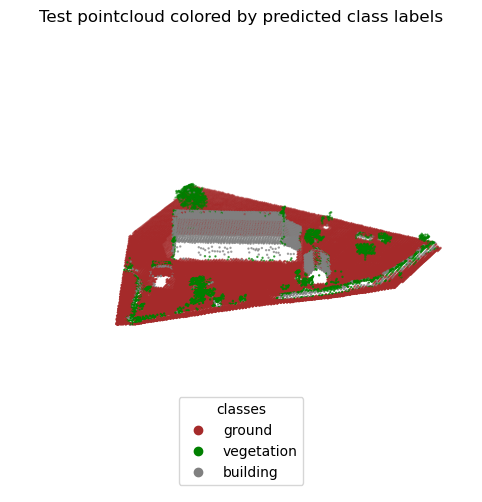

In [26]:
# Plot predicted labels on the test pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=y_pred, cmap=lidar_cmap, s=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Test pointcloud colored by predicted class labels")
# Create legend with class names
ax.legend(legend_handles, legend_labels, title="classes", loc="lower center")
plt.show()

### Regularization

The fourth step of the semantic segmentation pipeline is the **regularization** of predicted labels to enforce local consistency and remove isolated misclassifications. This step is optional but commonly applied. It relies on the assumption that neighboring points often belong to the same object and should therefore receive similar labels.

Common regularization techniques include:

* **Majority voting**, where each point is assigned the most frequent label among its neighbors.

* **Probability smoothing**, where class probabilities are averaged within a neighborhood before assigning the final label.

* **Markov Random Fields** (MRF) and **Conditional Random Fields** (CRF), which combine classifier predictions with spatial smoothness constraints.

In practice, simple probability smoothing already provides a significant improvement at a very low computational cost. However, CRFs are generally the go-to regularization method in production pipelines, often significantly improving spatial consistency and boundary accuracy.

Below, regularization is performed by probability smoothing. The final label is obtained by averaging the classifier probabilities over the $k$-neighborhood of each point and selecting the most probable class. This approach is generally good at correcting isolated classification errors, while remaining simple to implement.

In [27]:
# Probabilities from the RF classifier
proba = rf_clf.predict_proba(X_test)

# Smooth probabilities over neighbors
inds = kdtree.query(points, k=20, return_distance=False)
smoothed_proba = np.zeros_like(proba)
for i in range(len(proba)):
    smoothed_proba[i] = proba[inds[i]].mean(axis=0)

y_pred_smooth = smoothed_proba.argmax(axis=1)

Regularization improves the overall accuracy and significantly increases the classification quality of the vegetation class. This indicates that probability smoothing successfully corrects many isolated errors and enforces local consistency.

              precision    recall  f1-score   support

      ground       0.97      0.99      0.98     25236
  vegetation       0.87      0.85      0.86      2585
    building       0.98      0.91      0.94      5080

    accuracy                           0.97     32901
   macro avg       0.94      0.91      0.93     32901
weighted avg       0.97      0.97      0.97     32901



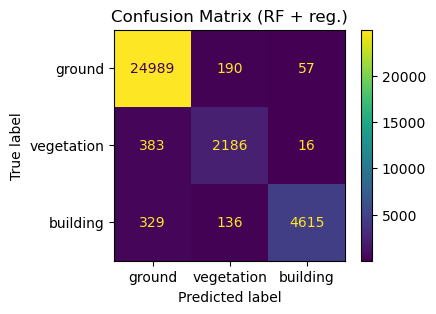

In [28]:
# Classification report
print(
    classification_report(y_test, y_pred_smooth, target_names=class_names.values())
)

# Evaluate the classifier using a confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
cmd_clf = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smooth,
    display_labels=class_names.values(),
    ax=ax
)
ax.set_title("Confusion Matrix (RF + reg.)")
plt.show()

The regularized classification is also more spatially coherent visually. This improvement is particularly noticeable on building roofs.

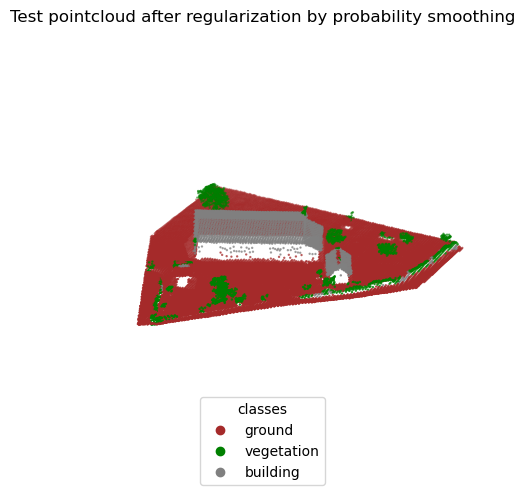

In [29]:
# Plot predicted labels on the test pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=y_pred_smooth, cmap=lidar_cmap, s=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Test pointcloud after regularization by probability smoothing")
# Create legend with class names
ax.legend(legend_handles, legend_labels, title="classes", loc="lower center")
plt.show()

## Wrapping up

You should now have a better grasp on how machine learning can be effectively applied to 3D point clouds. This notebook covered three areas where machine learning particularly shines: **cleaning**, **object segmentation**, and **semantic segmentation**. By leveraging both the geometric structure and statistical properties of the data, these methods provide solutions that are often more robust than purely geometric approaches while remaining efficient and interpretable.

For cleaning and object segmentation, machine learning models can often be used as **drop-in replacements** for classical geometric algorithms. **Local Outlier Factor (LOF)** improves **outlier detection** by identifying points that are inconsistent with their local neighborhood, making it a powerful alternative to threshold-based geometric filters. Similarly, clustering methods such as K-Means, DBSCAN, and Agglomerative Clustering can segment objects directly from the point cloud. In particular, **DBSCAN** often replaces traditional geometric **object segmentation** techniques while offering better handling of noise and objects with irregular shapes. Semantic segmentation, however, goes beyond geometry and assigns a semantic meaning to each point (such as ground, building, or vegetation). This type of understanding cannot be achieved with purely geometric algorithms alone, as it requires learning the relationship between geometric features and semantic classes from labeled examples.

While this notebook focused on cleaning, object segmentation, and semantic segmentation, machine learning also plays an important role in other pointcloud processing tasks, including classification, registration, feature matching, and change detection. However, the performance of classical machine learning models depends heavily on **feature engineering** or the design geometric descriptors that capture the relevant characteristics of the data. As tasks become more complex, identifying the most informative features becomes increasingly challenging.

This limitation naturally motivates the use of deep learning models, which learn hierarchical representations directly from raw point clouds or derived representations rather than relying on handcrafted features. As a result, they can capture more complex patterns and achieve state-of-the-art performance on tasks such as semantic segmentation. However, this additional power comes at the cost of increased complexity, lower interpretability, and a need for larger training datasets and computational resources. Classical machine learning therefore remains an excellent choice when data are limited, interpretability is important, or a simple and efficient solution is sufficient.